In [1]:
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, glob
import nilearn 
import nibabel as nib
from nibabel import processing
import config
import RM_utils as utils
from nilearn import datasets
from scipy import stats
from nilearn import plotting
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
from brainiak.searchlight.searchlight import Searchlight
import TPHATE.tphate 
from TPHATE.tphate import tphate
import scprep
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
from scipy.spatial.distance import pdist, cdist, squareform

/gpfs/milgram/project/casey/elb77/conda_envs/tphate_env/lib/python3.6/site-packages/nilearn/__init__.py:69: FutureWarning: Python 3.6 support is deprecated and will be removed in release 0.10 of Nilearn. Consider switching to Python 3.8 or 3.9.
  _python_deprecation_warnings()


In [8]:
# start with rest data

def get_subject_data(subject, task):
    dirname = config.RM_DATA_DIRS[task]
    try:
        fn = glob.glob(f"{dirname}/rest_movie_{subject:02d}_functional*_Only.nii.gz")[0]
    except:
        print(f'{dirname}/rest_movie_{subject:02d}_functional*_Only.nii.gz')
        return np.zeros((3,3))
    return nib.load(fn)

def mask_normalize_wb_data(nii_list, wb_mask, tr=2, n_trs=-1):
    masker_wb = NiftiMasker(mask_img=wb_mask,
    standardize=True,  # Are you going to zscore the data across time?
    t_r=tr
    )
    data_list = []
    for nii in nii_list:
        masked = masker_wb.fit_transform(nii)
        masked=masked[:n_trs]
        data_list.append(masked)
    data_arr = np.stack(data_list)
    return data_arr

def get_masked_wb_data(task, mask_str, subjects):
    fn = f'RestMovie/data/{task}_wb_data.npy'
    try:
        data_arr = np.load(fn)
        print(f'loaded data of shape {data_arr.shape} from {fn}')
    except:
        niis=[]
        for sub in subjects:
            nii = get_subject_data(sub, task)
            print(nii.shape[-1], task, sub)
            niis.append(nii)
        mask=f'masks/Adult_{mas}_intersect_mask.nii.gz'
        data_arr = mask_normalize_wb_data(niis, mask, n_trs=config.RM_TIMEPOINTS[task])
        np.save(fn, data_arr)
        print(f'saved data of shape {data_arr.shape} to {fn}')
    return data_arr
    
def embed_wb_data(sub, task, X):
    fn_opt = f'RestMovie/data/embeddings/sub-{sub:02d}_{task}_tphate_embedding_topt.npy'
    fn_2d = f'RestMovie/data/embeddings/sub-{sub:02d}_{task}_tphate_embedding_2d_t4.npy'
    
    try:
        opt_embd = np.load(fn_opt)
        vis_embd = np.load(fn_2d)
        opt_t = None 
        drop = None
    except:
        op = tphate.TPHATE(verbose=0).fit(X)
        e = op.transform(arr)
        opt_t = op.optimal_t
        drop = op.dropoff

        opt_embd = tphate.TPHATE(verbose=0, n_components=opt_t).fit_transform(X)
        np.save(fn_opt, opt_embd)

        vis_embd = tphate.TPHATE(verbose=0, n_components=2, t=4).fit_transform(X)
        np.save(fn_2d, vis_embd)
    return opt_embd, vis_embd, opt_t, drop

def visualize_tphate(sub, task, X, opt_t=None, drop=None, rerun=False):
    fn = f'RestMovie/data/embeddings/sub-{sub:02d}_{task}_tphate_embedding_2d_t4.npy'
    if rerun:
        os.remove(fn)
    try:
        x = np.load(fn)
    except:
        print(f"{fn} DNE; running")
        op = tphate.TPHATE(verbose=0).fit(X)
        e = op.transform(X)
        opt_t = op.optimal_t
        drop = op.dropoff
        x = tphate.TPHATE(verbose=0, n_components=2, t=4).fit_transform(X)
        np.save(fn, x)
        
    title=f'sub {i+1}'
    if opt_t !=None: title+=f' drop={drop}, opt_t={opt_t}'

    filename=f'RestMovie/plots/sub-{sub:02d}_{task}_tphate_wb.png'
    scprep.plot.scatter2d(x, c=np.arange(len(x)), title=title, ticks=False, filename=filename)
    print(filename)
    return opt_t, drop

## Whole brain resting state


loaded data of shape (12, 152, 71002) from RestMovie/data/REST_wb_data.npy
did embeddings sub 1
RestMovie/data/embeddings/sub-01_REST_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-01_REST_tphate_wb.png
did embeddings sub 2
RestMovie/data/embeddings/sub-02_REST_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-02_REST_tphate_wb.png
did embeddings sub 3
RestMovie/data/embeddings/sub-03_REST_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-03_REST_tphate_wb.png
did embeddings sub 4
RestMovie/data/embeddings/sub-04_REST_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-04_REST_tphate_wb.png
did embeddings sub 5
RestMovie/data/embeddings/sub-05_REST_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-05_REST_tphate_wb.png
did embeddings sub 6
RestMovie/data/embeddings/sub-06_REST_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-06_REST_tphate_wb.png
did embeddings sub 7
RestMovie/data/embeddings/sub-07_REST_tphate_embedding_2d_

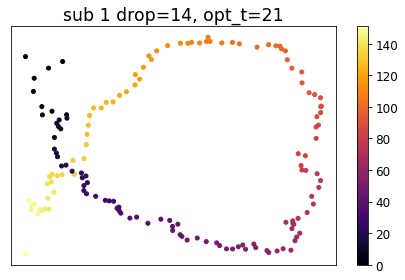

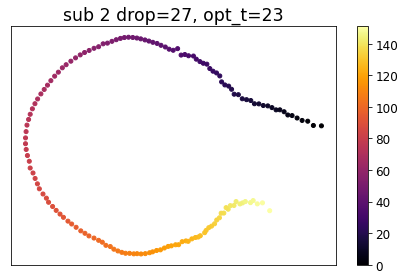

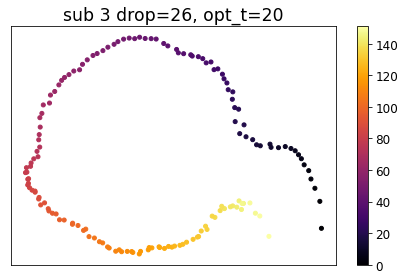

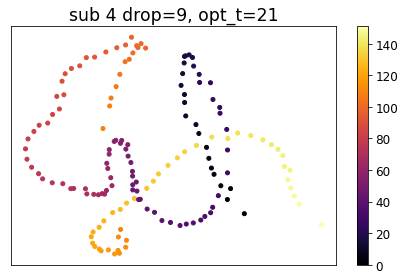

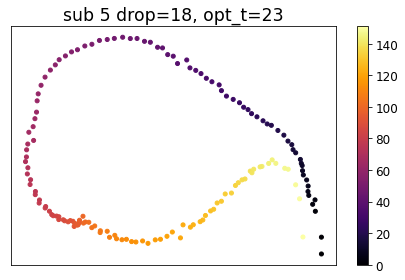

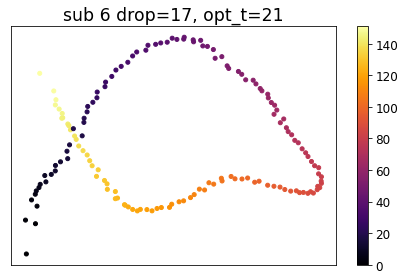

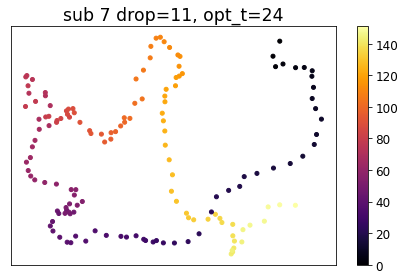

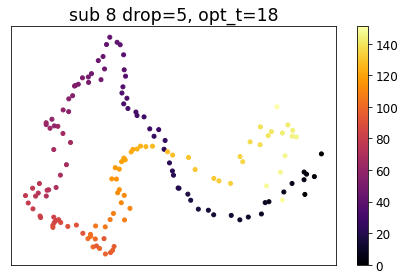

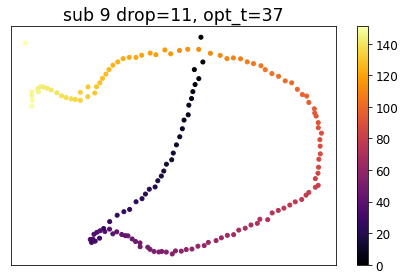

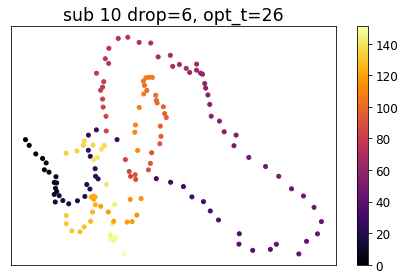

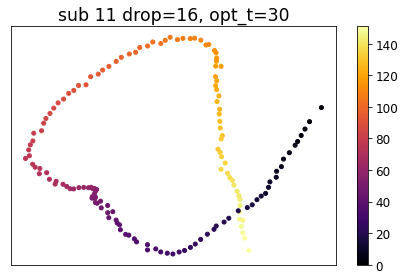

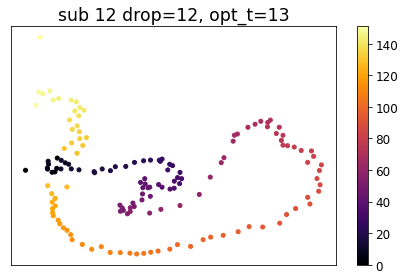

In [13]:
task = 'REST'
mas = 'Rest'
data_arr = get_masked_wb_data(task, mas)
dropoffs, Ts = [], []
for i, sub, arr in zip(np.arange(len(data_arr)), config.RM_SUBJECTS, data_arr):
    opt_embd, vis_embd, opt_t, drop = embed_wb_data(sub, task, arr)
    print(f'did embeddings sub {sub}')
    opt_t, drop = visualize_tphate(sub, task, arr, opt_t=opt_t, drop=drop, rerun=True)
    dropoffs.append(drop)
    Ts.append(opt_t)

In [14]:
np.save(f'RestMovie/results/{task}_optimal_t_WB.npy', Ts)
np.save(f'RestMovie/results/{task}_autocorrelation_WB.npy', dropoffs)


## Whole brain aeronaut


loaded data of shape (12, 93, 71824) from RestMovie/data/AERONAUT_wb_data.npy
did embeddings sub 1
RestMovie/plots/sub-01_AERONAUT_tphate_wb.png
RestMovie/data/embeddings/sub-01_AERONAUT_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-01_AERONAUT_tphate_wb.png
did embeddings sub 2
RestMovie/plots/sub-02_AERONAUT_tphate_wb.png
RestMovie/data/embeddings/sub-02_AERONAUT_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-02_AERONAUT_tphate_wb.png
did embeddings sub 3
RestMovie/plots/sub-03_AERONAUT_tphate_wb.png
RestMovie/data/embeddings/sub-03_AERONAUT_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-03_AERONAUT_tphate_wb.png
did embeddings sub 4
RestMovie/plots/sub-04_AERONAUT_tphate_wb.png
RestMovie/data/embeddings/sub-04_AERONAUT_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-04_AERONAUT_tphate_wb.png
did embeddings sub 5
RestMovie/plots/sub-05_AERONAUT_tphate_wb.png
RestMovie/data/embeddings/sub-05_AERONAUT_tphate_embedding_2d_t4.npy DNE; r

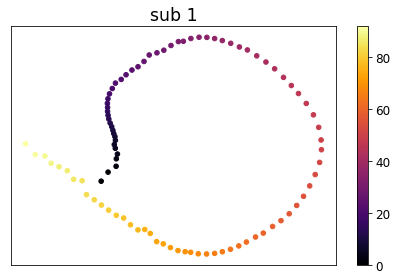

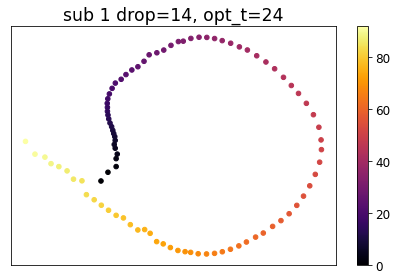

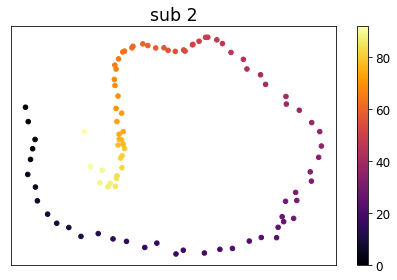

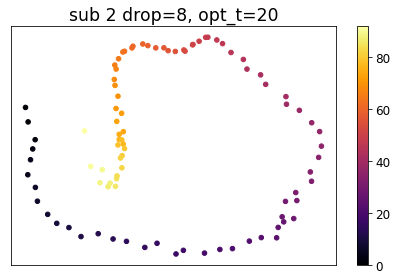

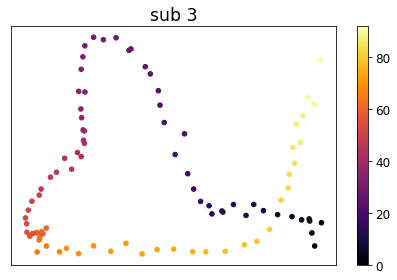

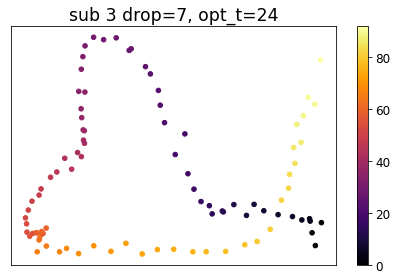

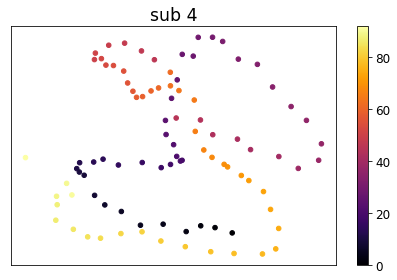

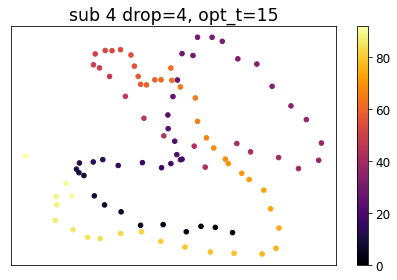

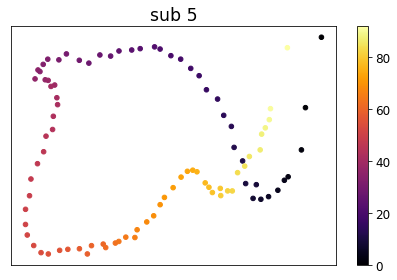

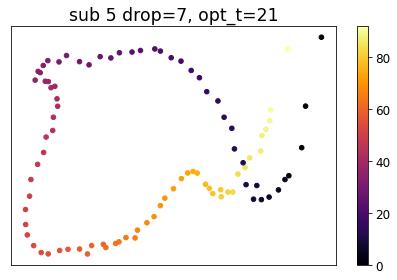

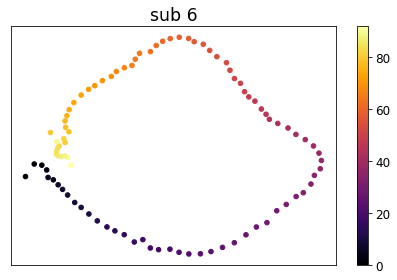

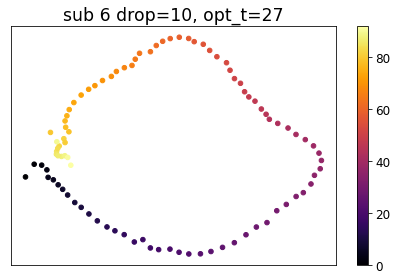

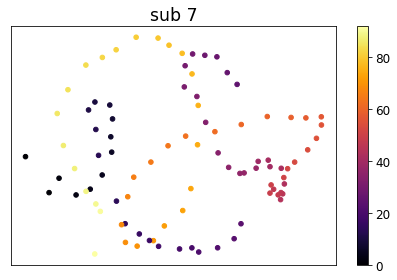

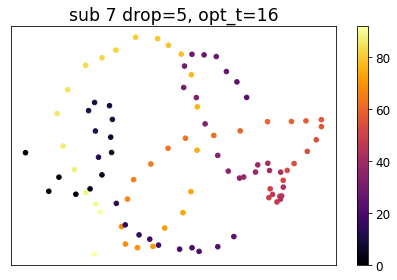

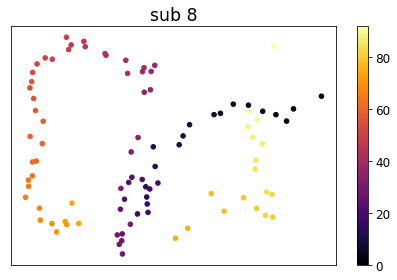

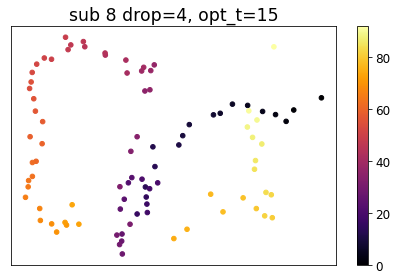

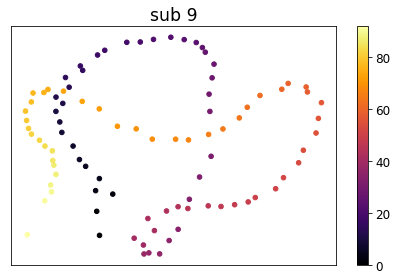

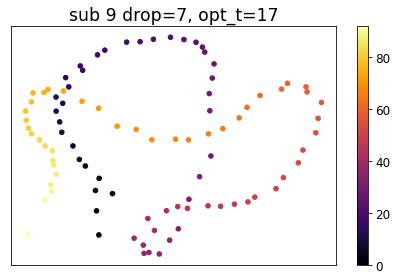

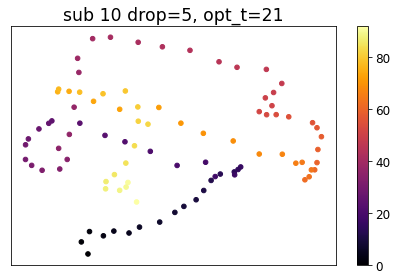

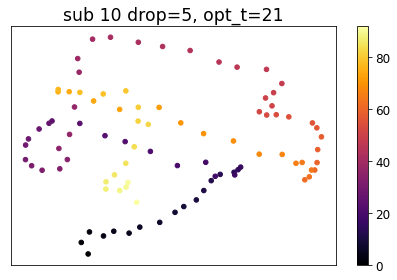

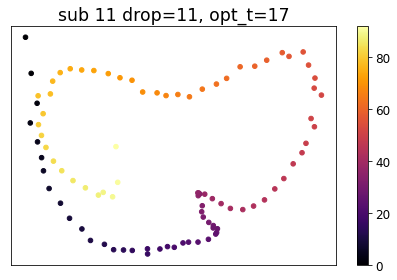

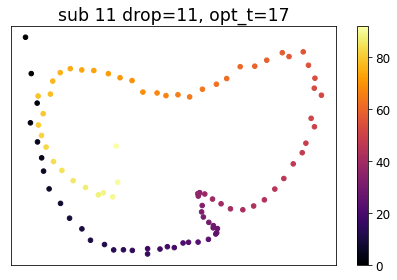

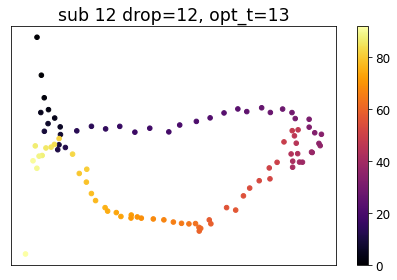

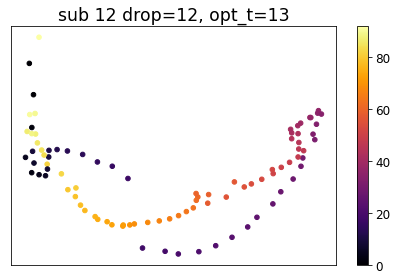

In [16]:
task = 'AERONAUT'
mas = 'Aeronaut'
data_arr = get_masked_wb_data(task, mas)
dropoffs, Ts = [], []

for i, sub, arr in zip(np.arange(len(data_arr)), config.RM_SUBJECTS, data_arr):
    opt_embd, vis_embd, opt_t, drop = embed_wb_data(sub, task, arr)
    print(f'did embeddings sub {sub}')
    visualize_tphate(sub, task, arr, opt_t=opt_t, drop=drop)
    opt_t, drop = visualize_tphate(sub, task, arr, opt_t=opt_t, drop=drop, rerun=True)
    dropoffs.append(drop)
    Ts.append(opt_t)
np.save(f'RestMovie/results/{task}_optimal_t_WB.npy', Ts)
np.save(f'RestMovie/results/{task}_autocorrelation_WB.npy', dropoffs)


## Whole brain mickey

76 MICKEY 1
75 MICKEY 2
75 MICKEY 3
76 MICKEY 4
75 MICKEY 5
75 MICKEY 7
76 MICKEY 8
75 MICKEY 9
75 MICKEY 10
75 MICKEY 11
75 MICKEY 12
saved data of shape (11, 74, 73007) to RestMovie/data/MICKEY_wb_data.npy
did embeddings sub 1
RestMovie/data/embeddings/sub-01_MICKEY_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-01_MICKEY_tphate_wb.png
did embeddings sub 2
RestMovie/data/embeddings/sub-02_MICKEY_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-02_MICKEY_tphate_wb.png
did embeddings sub 3
RestMovie/data/embeddings/sub-03_MICKEY_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-03_MICKEY_tphate_wb.png
did embeddings sub 4
RestMovie/data/embeddings/sub-04_MICKEY_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-04_MICKEY_tphate_wb.png
did embeddings sub 5
RestMovie/data/embeddings/sub-05_MICKEY_tphate_embedding_2d_t4.npy DNE; running
RestMovie/plots/sub-05_MICKEY_tphate_wb.png
did embeddings sub 7
RestMovie/data/embeddings/sub-07_MICKEY_tphate

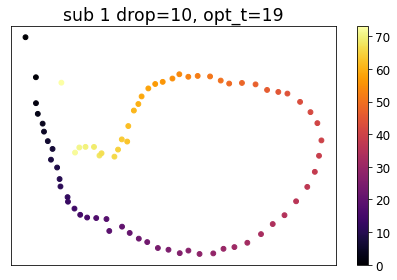

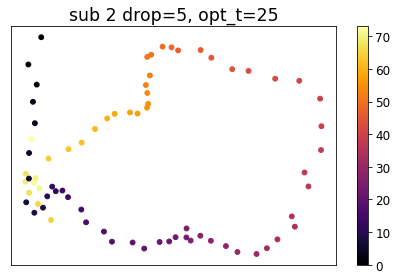

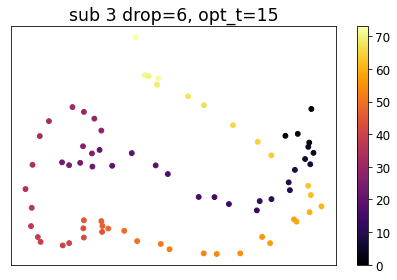

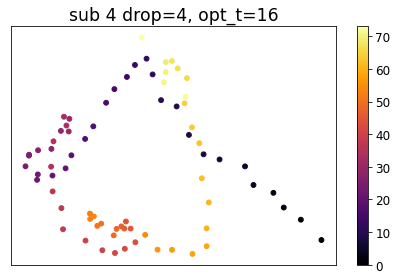

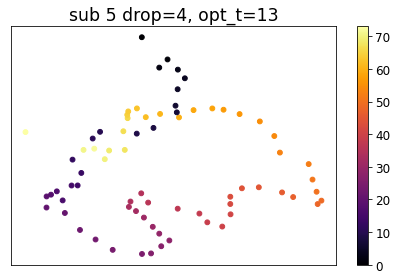

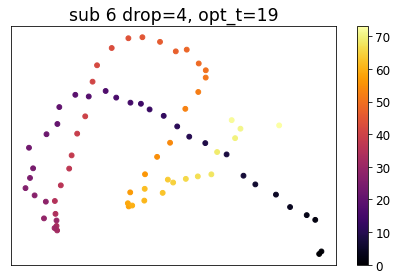

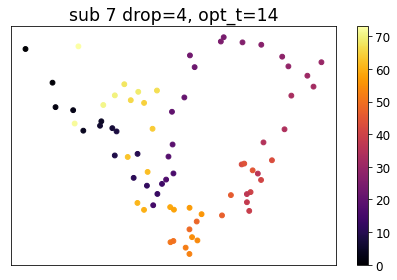

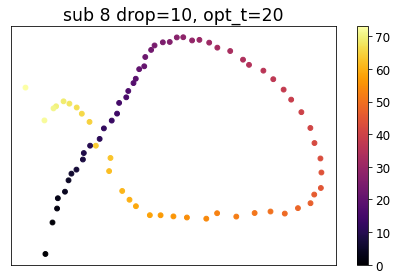

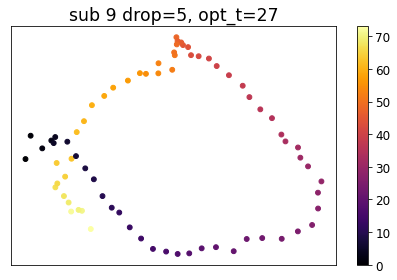

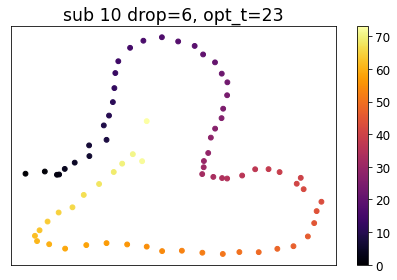

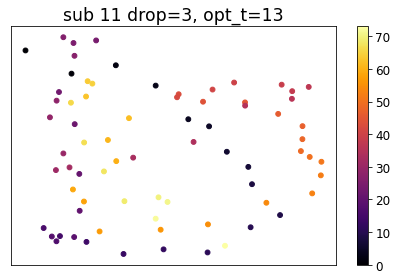

In [21]:
task = 'MICKEY'
mas = 'Mickey'
subjects = [c for c in config.RM_SUBJECTS if c!=6]
data_arr = get_masked_wb_data(task, mas, subjects)
dropoffs, Ts = [], []

for i, sub, arr in zip(np.arange(len(data_arr)), subjects, data_arr):
    if sub == 6:
        dropoffs.append(np.nan)
        Ts.append(np.nan)
        print(arr.shape, sub, 'skip')
        continue
    opt_embd, vis_embd, opt_t, drop = embed_wb_data(sub, task, arr)
    print(f'did embeddings sub {sub}')
    opt_t, drop = visualize_tphate(sub, task, arr, opt_t=opt_t, drop=drop, rerun=True)
    dropoffs.append(drop)
    Ts.append(opt_t)
np.save(f'RestMovie/results/{task}_optimal_t_WB.npy', Ts)
np.save(f'RestMovie/results/{task}_autocorrelation_WB.npy', dropoffs)


## Test searchlight stuff

In [19]:
def get_subject_data(sub_id, task):
    dirname = config.RM_DATA_DIRS[task]
    print(f"{dirname}/rest_movie_{sub_id:02d}_functional*_Only.nii.gz")
    fn = sorted(glob.glob(f"{dirname}/rest_movie_{sub_id:02d}_functional*_Only.nii.gz"))[0]
    return nib.load(fn)

In [18]:
# Load and prepare data for one subject
def load_data(sub_id, task):
    
    # Load bold data and some header information so that we can save searchlight results as nifti later.
    nii = utils.get_subject_data(sub_id, task)
    # Load mask
    brain_mask = utils.get_mask(task)
    masker_wb = NiftiMasker(mask_img=brain_mask, standardize=True)
    masked_normed = masker_wb.fit_transform(nii)
    masked_nii = masker_wb.inverse_transform(masked_normed)
    
    bold_data = masked_nii.get_fdata()
    affine_mat = masked_nii.affine
    dimensions = masked_nii.header.get_zooms() 
    
    return bold_data, brain_mask.get_fdata(), affine_mat, dimensions

    
def tphate_kernel(data, sl_mask, myrad, bcvar):
    data=data[0]
    num_voxels_in_sl = sl_mask.shape[0] * sl_mask.shape[1] * sl_mask.shape[2]
    n_timepoints = data.shape[-1]
    data_arr = data.reshape(num_voxels_in_sl, n_timepoints).T # data should already be normed
    op = tphate.TPHATE(verbose=0).fit(data_arr)
    eb = op.transform(data_arr)
    if verbose:
        print(f'got t={op.optimal_t}, ac={op.dropoff}')
    return op.optimal_t, op.dropoff

In [9]:
11750/ 125

94.0

In [114]:
# Pull out the MPI information
# comm = MPI.COMM_WORLD
# rank = comm.rank
# size = comm.size
sub_id = 1
task = 'Rest'.upper()
rank=0
data,bcvar,masks,affines,dimsizes = [],[],[],[],[]

if rank == 0:
    data_i, mask, affine_mat, dimsize = load_data(sub_id, task)
    data.append(data_i)
    masks.append(mask)
    affines.append(affine_mat)
    dimsizes.append(dimsize)
    bcvar.append([])
else:
    data.append(None)
    
    
sl_rad = 5
max_blk_edge = 5
pool_size = 1


my_small_mask = np.zeros(mask.shape)
x,y,z = [16,20,16]

my_small_mask[x-2:x+2, y-2:y+2, z-2:z+2] = 1
# Create the searchlight object
sl = Searchlight(sl_rad=sl_rad,max_blk_edge=max_blk_edge)

# Distribute the information to the searchlights (preparing it to run)
sl.distribute(data, my_small_mask)

# Broadcast variables
sl.broadcast(bcvar)
verbose=False



# Run the searchlight analysis
print(f"Begin Searchlight in rank {rank}")
all_sl_result = sl.run_searchlight(tphate_kernel, pool_size=pool_size)
print(f"End Searchlight in rank {rank}")

Begin Searchlight in rank 0
End Searchlight in rank 0


## analyze searchlight results 

### difference between tasks TPHATE

In [33]:
# difference between tasks
SL_RAD = 5
mask = utils.get_mask("REST").get_fdata() # this has the fewest voxels
masker_wb = NiftiMasker(mask_img=mask, standardize=False)
res_dir = './RestMovie/results/SEARCHLIGHT/TPHATE'
TASKS = config.RM_SUBJECTS.keys()
coords = np.where(mask==1)
print(np.shape(coords))
difference_volumes = {"REST-AERONAUT":[], "REST-MICKEY":[], "AERONAUT-MICKEY":[]}

for sub in config.RM_SUBJECTS['MICKEY']:
    data_masked = {}
    for task in TASKS:
        nii = nib.load(f'{res_dir}/sub-{sub:02d}_{task}_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz')
        vol=nii.get_fdata()
        masked = vol[coords]
        data_masked[task] = masked
    
    for task_pair in [("REST","AERONAUT"), ("REST","MICKEY"), ("AERONAUT","MICKEY")]:
        d0, d1 = data_masked[task_pair[0]], data_masked[task_pair[1]]
        string=f'{task_pair[0]}-{task_pair[1]}'
        outfn = f'{res_dir}/sub-{sub:02d}_{string}_diff_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz'
        diff = d0 - d1
        difference_volumes[string].append(diff)
        out_vol = np.zeros_like(mask)
        out_vol[coords] = diff
        print(sub, task_pair, np.nanmin(diff), np.round(np.nanmean(diff),2), np.nanmax(diff))
        nii_res = nib.Nifti1Image(out_vol, nii.affine)
        nii_res.header.set_zooms(nii.header.get_zooms())
        nib.save(nii_res, outfn) 
        

(3, 71002)
1 ('REST', 'AERONAUT') -13.0 -0.23 26.0 0
1 ('REST', 'MICKEY') -16.0 -3.34 25.0 0
1 ('AERONAUT', 'MICKEY') -26.0 -3.11 21.0 0
2 ('REST', 'AERONAUT') -7.0 2.32 26.0 0
2 ('REST', 'MICKEY') -7.0 2.04 26.0 0
2 ('AERONAUT', 'MICKEY') -21.0 -0.28 23.0 0
3 ('REST', 'AERONAUT') -13.0 -0.05 30.0 0
3 ('REST', 'MICKEY') -7.0 2.8 30.0 0
3 ('AERONAUT', 'MICKEY') -21.0 2.86 29.0 0
4 ('REST', 'AERONAUT') -7.0 1.48 19.0 0
4 ('REST', 'MICKEY') -6.0 1.26 19.0 0
4 ('AERONAUT', 'MICKEY') -16.0 -0.22 18.0 0
5 ('REST', 'AERONAUT') -13.0 -0.12 26.0 0
5 ('REST', 'MICKEY') -8.0 1.72 26.0 0
5 ('AERONAUT', 'MICKEY') -15.0 1.84 21.0 0
7 ('REST', 'AERONAUT') -8.0 2.55 25.0 0
7 ('REST', 'MICKEY') -13.0 2.27 27.0 0
7 ('AERONAUT', 'MICKEY') -21.0 -0.28 16.0 0
8 ('REST', 'AERONAUT') -10.0 1.62 23.0 0
8 ('REST', 'MICKEY') -7.0 2.77 22.0 0
8 ('AERONAUT', 'MICKEY') -18.0 1.15 22.0 0
9 ('REST', 'AERONAUT') -4.0 9.13 30.0 0
9 ('REST', 'MICKEY') -10.0 5.14 32.0 0
9 ('AERONAUT', 'MICKEY') -23.0 -3.99 16.0 0
10 ('R

In [24]:
from scipy.stats import ttest_1samp

In [82]:
tstats, pvals, means, medians = {}, {}, {}, {}
for key, value in difference_volumes.items():
    difference_volumes[key] = np.nan_to_num(np.array(value))
    t, p = ttest_1samp(difference_volumes[key], popmean=0, axis=0)
    tstats[key]=t
    pvals[key]=p
    m=np.mean(np.nan_to_num(np.array(value)), axis=0)
    means[key]=m
    med=np.median(np.nan_to_num(np.array(value)), axis=0)
    medians[key]=med
    for val, typ in zip([t, p, m, med], ['tstat','pvalue','average','median']):
        out_vol = np.zeros_like(mask)
        out_vol[coords] = val
        outfn = f'./RestMovie/results/AGGREGATE/{key}_diff_{typ}_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz'
        nii_res = nib.Nifti1Image(out_vol, nii.affine)
        nii_res.header.set_zooms(nii.header.get_zooms())
        nib.save(nii_res, outfn)
        print(outfn, np.round(np.nanmean(val),2) )

./RestMovie/results/AGGREGATE/REST-AERONAUT_diff_tstat_optimal_t_whole_brain_SL_rad5.nii.gz 2.1
./RestMovie/results/AGGREGATE/REST-AERONAUT_diff_pvalue_optimal_t_whole_brain_SL_rad5.nii.gz 0.17
./RestMovie/results/AGGREGATE/REST-AERONAUT_diff_average_optimal_t_whole_brain_SL_rad5.nii.gz 2.23
./RestMovie/results/AGGREGATE/REST-AERONAUT_diff_median_optimal_t_whole_brain_SL_rad5.nii.gz 1.96
./RestMovie/results/AGGREGATE/REST-MICKEY_diff_tstat_optimal_t_whole_brain_SL_rad5.nii.gz 1.56
./RestMovie/results/AGGREGATE/REST-MICKEY_diff_pvalue_optimal_t_whole_brain_SL_rad5.nii.gz 0.3
./RestMovie/results/AGGREGATE/REST-MICKEY_diff_average_optimal_t_whole_brain_SL_rad5.nii.gz 1.52
./RestMovie/results/AGGREGATE/REST-MICKEY_diff_median_optimal_t_whole_brain_SL_rad5.nii.gz 1.54
./RestMovie/results/AGGREGATE/AERONAUT-MICKEY_diff_tstat_optimal_t_whole_brain_SL_rad5.nii.gz -0.82
./RestMovie/results/AGGREGATE/AERONAUT-MICKEY_diff_pvalue_optimal_t_whole_brain_SL_rad5.nii.gz 0.45
./RestMovie/results/AGGREG

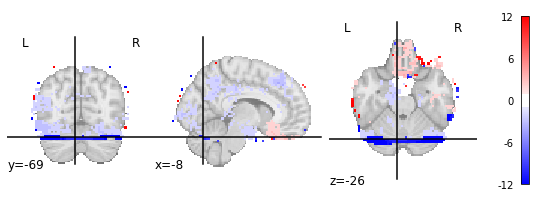

In [84]:
fn='./RestMovie/results/AGGREGATE/AERONAUT-MICKEY_diff_median_optimal_t_whole_brain_SL_rad5.nii.gz'
plotting.plot_stat_map(fn, threshold=1, cmap='bwr', vmax=12)

### difference between tasks - phate and pca


In [16]:
# difference between tasks
SL_RAD = 5
mask = utils.get_mask("REST").get_fdata() # this has the fewest voxels
masker_wb = NiftiMasker(mask_img=mask, standardize=False)
from scipy.stats import ttest_1samp

for method, string1 in zip(["PCA","PHATE"], ['PCA_95p_var', 'phate_optt']):
    res_dir = f'./RestMovie/results/SEARCHLIGHT/{method}'
    TASKS = config.RM_SUBJECTS.keys()
    coords = np.where(mask==1)
    difference_volumes = {"REST-AERONAUT":[], "REST-MICKEY":[], "AERONAUT-MICKEY":[]}
    for sub in config.RM_SUBJECTS['MICKEY']:
        data_masked = {}
        for task in TASKS:
            try:
                nii = nib.load(f'{res_dir}/sub-{sub:02d}_{task}_{string1}_whole_brain_SL_rad{SL_RAD}.nii.gz')
            except:
                nii=nii
            vol=nii.get_fdata()
            masked = vol[coords]
            data_masked[task] = masked

        for task_pair in [("REST","AERONAUT"), ("REST","MICKEY"), ("AERONAUT","MICKEY")]:
            d0, d1 = data_masked[task_pair[0]], data_masked[task_pair[1]]
            string=f'{task_pair[0]}-{task_pair[1]}'
            outfn = f'{res_dir}/sub-{sub:02d}_{string}_diff_{string}_whole_brain_SL_rad{SL_RAD}.nii.gz'
            diff = d0 - d1
            difference_volumes[string].append(diff)
            out_vol = np.zeros_like(mask)
            out_vol[coords] = diff
            print(sub, task_pair, np.nanmin(diff), np.round(np.nanmean(diff),2), np.nanmax(diff))
            nii_res = nib.Nifti1Image(out_vol, nii.affine)
            nii_res.header.set_zooms(nii.header.get_zooms())
            nib.save(nii_res, outfn) 
    tstats, pvals, means, medians = {}, {}, {}, {}
    for key, value in difference_volumes.items():
        difference_volumes[key] = np.nan_to_num(np.array(value))
        t, p = ttest_1samp(difference_volumes[key], popmean=0, axis=0)
        tstats[key]=t
        pvals[key]=p
        m=np.mean(np.nan_to_num(np.array(value)), axis=0)
        means[key]=m
        med=np.median(np.nan_to_num(np.array(value)), axis=0)
        medians[key]=med
        for val, typ in zip([t, p, m, med], ['tstat','pvalue','average','median']):
            out_vol = np.zeros_like(mask)
            out_vol[coords] = val
            outfn = f'./RestMovie/results/AGGREGATE/{key}_diff_{typ}_{string1}_whole_brain_SL_rad{SL_RAD}.nii.gz'
            nii_res = nib.Nifti1Image(out_vol, nii.affine)
            nii_res.header.set_zooms(nii.header.get_zooms())
            nib.save(nii_res, outfn)
            print(outfn, np.round(np.nanmean(val),2) )   

1 ('REST', 'AERONAUT') 0.0 28.99 65.0
1 ('REST', 'MICKEY') 0.0 24.28 64.0
1 ('AERONAUT', 'MICKEY') -37.0 -4.7 30.0
2 ('REST', 'AERONAUT') -9.0 11.86 60.0
2 ('REST', 'MICKEY') -6.0 19.36 60.0
2 ('AERONAUT', 'MICKEY') -44.0 7.51 50.0
3 ('REST', 'AERONAUT') -3.0 13.4 63.0
3 ('REST', 'MICKEY') -4.0 18.14 64.0
3 ('AERONAUT', 'MICKEY') -44.0 4.73 50.0
4 ('REST', 'AERONAUT') -3.0 14.87 70.0
4 ('REST', 'MICKEY') -5.0 19.68 71.0
4 ('AERONAUT', 'MICKEY') -48.0 4.81 56.0
5 ('REST', 'AERONAUT') -3.0 13.53 71.0
5 ('REST', 'MICKEY') -3.0 19.75 73.0
5 ('AERONAUT', 'MICKEY') -49.0 6.23 54.0
7 ('REST', 'AERONAUT') 0.0 22.18 65.0
7 ('REST', 'MICKEY') 0.0 19.87 66.0
7 ('AERONAUT', 'MICKEY') -44.0 -2.31 45.0
8 ('REST', 'AERONAUT') -6.0 9.58 60.0
8 ('REST', 'MICKEY') -7.0 11.48 60.0
8 ('AERONAUT', 'MICKEY') -44.0 1.89 47.0
9 ('REST', 'AERONAUT') -13.0 4.3 57.0
9 ('REST', 'MICKEY') -10.0 13.64 59.0
9 ('AERONAUT', 'MICKEY') -41.0 9.34 55.0
10 ('REST', 'AERONAUT') -9.0 9.48 60.0
10 ('REST', 'MICKEY') -5.0 15.

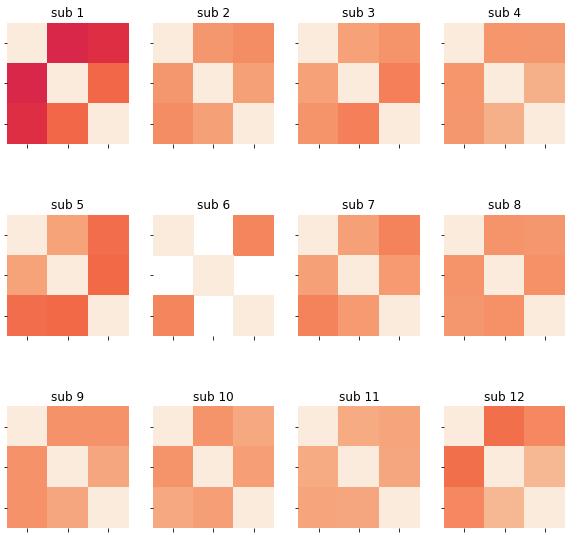

In [49]:
fig,ax=plt.subplots(3,4, figsize=(10,10))
ax=ax.ravel()
k = 2
j=0
for i in range(12):
    A = all_res[:,k,i,:]
    R = 1-squareform(pdist(A, metric='correlation'))
    sns.heatmap(R, square=True,ax=ax[j], vmin=0,vmax=1, cbar=False)
    ax[j].set_title(f'sub {i+1}') #{rad} dimensionality maps, {task}')
    ax[j].set(xticklabels=[], yticklabels=[])
    j+=1

In [36]:
a = {'a':'b'}
for i,j in a.items():
    print(i,j)

a b


In [42]:

for sub in config.RM_SUBJECTS["AERONAUT"][:5]:
    DATA = {}
    for task in ['rest','aeronaut','mickey']:
        TASK = task.upper()
        for rad in [3,5,8]:
            try:
                data = nib.load(f'./RestMovie/results/sub-{sub:02d}_{TASK}_optimal_t_whole_brain_SL_rad{rad}.nii.gz')
                DATA[f'{TASK}_{rad}'] = data
            except:
                continue
            
    maxx = np.max([np.nanmax(d.get_fdata()) for t,d in DATA.items()])
    minn =  1
    for KEY, VALUE in DATA.items():
        task, rad = KEY.split('_')
        ti=f'sub {sub} {task} sl rad {rad} dimensionality'
        print(ti)
        outfn = f'./RestMovie/plots/common_cbar/sub-{sub:02d}_{task.upper()}_optimal_t_whole_brain_SL_rad{rad}.png'
        # if os.path.exists(outfn):
        #     print(f'ran {outfn}')
        #     continue
        plotting.plot_glass_brain(VALUE, alpha=0.7, cmap='gist_rainbow', output_file=outfn, threshold=1, vmax=maxx, colorbar=True, title=ti)


sub 1 REST sl rad 3 dimensionality
sub 1 REST sl rad 5 dimensionality
sub 1 REST sl rad 8 dimensionality
sub 1 AERONAUT sl rad 3 dimensionality
sub 1 AERONAUT sl rad 5 dimensionality
sub 1 AERONAUT sl rad 8 dimensionality
sub 1 MICKEY sl rad 3 dimensionality
sub 1 MICKEY sl rad 5 dimensionality
sub 1 MICKEY sl rad 8 dimensionality
sub 2 REST sl rad 3 dimensionality
sub 2 REST sl rad 5 dimensionality
sub 2 REST sl rad 8 dimensionality
sub 2 AERONAUT sl rad 3 dimensionality
sub 2 AERONAUT sl rad 5 dimensionality
sub 2 AERONAUT sl rad 8 dimensionality
sub 2 MICKEY sl rad 3 dimensionality
sub 2 MICKEY sl rad 5 dimensionality
sub 2 MICKEY sl rad 8 dimensionality
sub 3 REST sl rad 3 dimensionality
sub 3 REST sl rad 5 dimensionality
sub 3 REST sl rad 8 dimensionality
sub 3 AERONAUT sl rad 3 dimensionality
sub 3 AERONAUT sl rad 5 dimensionality
sub 3 AERONAUT sl rad 8 dimensionality
sub 3 MICKEY sl rad 3 dimensionality
sub 3 MICKEY sl rad 5 dimensionality
sub 3 MICKEY sl rad 8 dimensionality
s

TypeError: inner() got multiple values for argument 'ax'

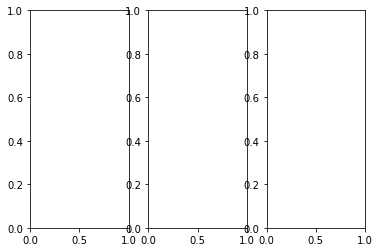

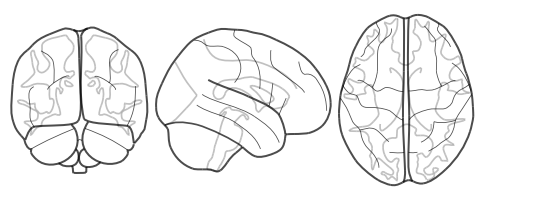

In [28]:
fig,ax=plt.subplots(1,3)
plotting.plot_glass_brain(REST, alpha=0.7, cmap='gist_rainbow', threshold=1,colorbar=True,ax=ax[0])
plotting.plot_glass_brain(REST, alpha=0.7, cmap='rainbow', threshold=1,colorbar=True,ax=ax[1])


(<Figure size 288x612 with 9 Axes>,
  <matplotlib.axes._subplots.AxesSubplot at 0x2b99f749f7f0>])

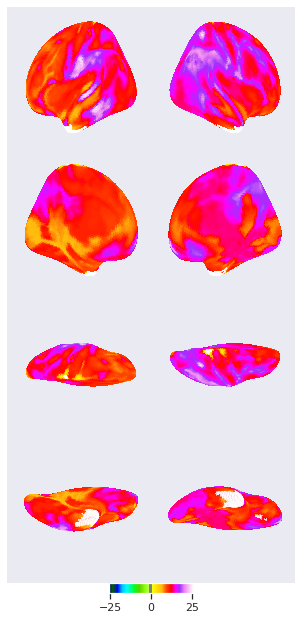

In [7]:
sub=1
rad=3
# fig,ax=plt.subplots(1,1,figsize=(6,8))
fn=f'./RestMovie/results/SEARCHLIGHT/TPHATE/sub-{sub:02d}_REST_optimal_t_whole_brain_SL_rad{rad}.nii.gz'
REST = nib.load(fn)
rest_mask = utils.get_mask("REST")
plotting.plot_img_on_surf(REST, views=['lateral','medial','dorsal','ventral'],
                          mask_img=rest_mask, inflate=True,cmap='gist_ncar', threshold=1, symmetric_cbar=False, alpha=0.5, darkness=0)
# fsaverage = nilearn.datasets.fetch_surf_fsaverage()
# from nilearn import surface
# texture = surface.vol_to_surf(REST, fsaverage.pial_left)
# plotting.plot_surf_stat_map(fsaverage.infl_left, texture)

In [42]:
dimensionality_results.max()

38.0

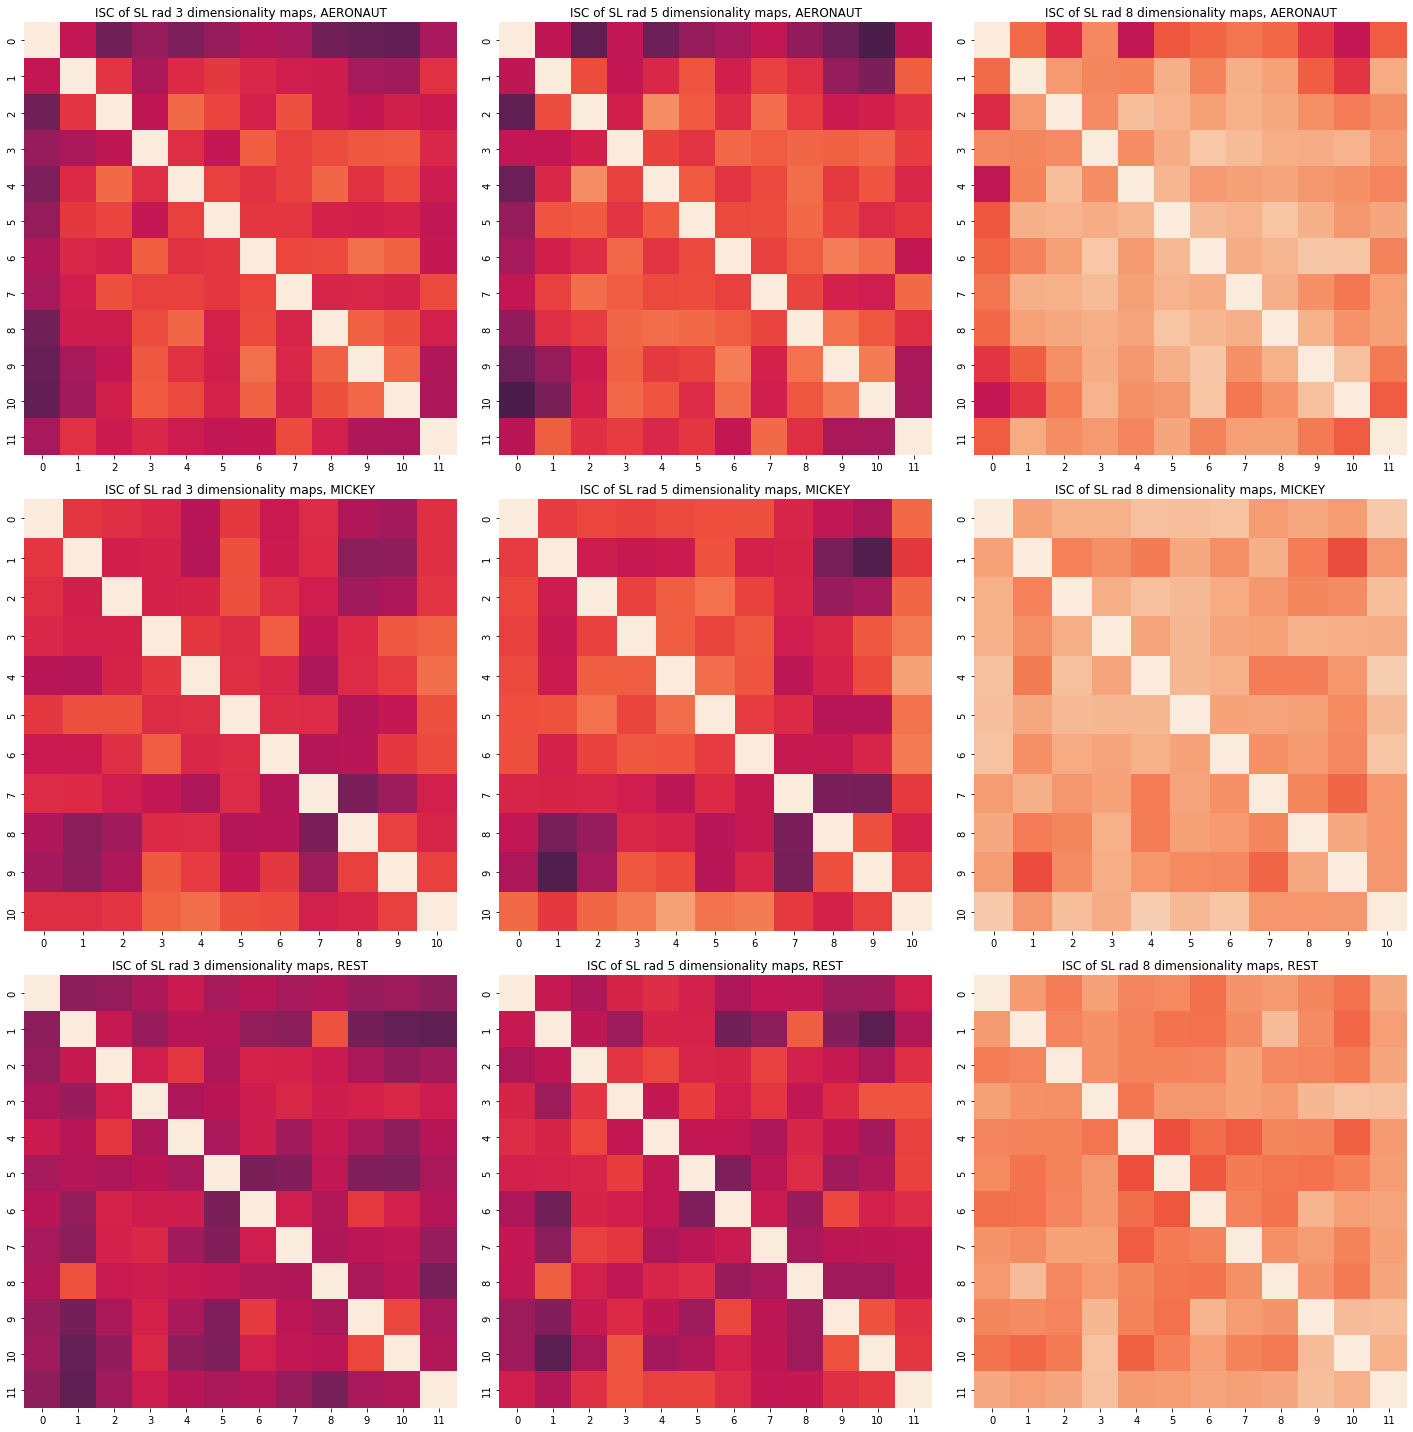

In [37]:
fig,ax=plt.subplots(3,3,figsize=(20,20))
ax=ax.ravel()
j=0
for t, task in enumerate(['AERONAUT','MICKEY','REST']):
    X = np.load(f'RestMovie/results/{task}_all_subject_sl_results.npy')
    # correlate subjects, within searchlight width and across voxels
    for r, rad in enumerate([3,5,8]):
        Xrad = X[r]
        if task == 'MICKEY':
            m=[0,1,2,3,4,6,7,8,9,10,11]
            Xrad = Xrad[m]
        R = 1-squareform(pdist(Xrad, metric='correlation'))
        sns.heatmap(R, square=True,ax=ax[j], vmin=0,vmax=1, cbar=False)
        ax[j].set_title(f'ISC of SL rad {rad} dimensionality maps, {task}')
        j +=1
fig.tight_layout()

In [14]:
for t, task in enumerate(['AERONAUT','MICKEY','REST']):
    for s, sl_rad in enumerate([3,5,8]):
        mask = utils.get_mask(task)
        n_subjects = 12 if task != "MICKEY" else 11
        all_vol = np.zeros((n_subjects, mask.shape[0], mask.shape[1], mask.shape[2]))
    
        for i, sub in enumerate(utils.RM_SUBJECTS[task]):
            vol = utils.get_result_vol(sub, task, sl_rad, 'optimal_t')
            all_vol[i] = vol.get_fdata()
        
        avg_vol = np.mean(all_vol,axis=0)
        avg_nii = nib.Nifti1Image(avg_vol, vol.affine)
        avg_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/results/average_optimal_t_{task}_sl_rad{sl_rad}.nii.gz'
        # nib.save(avg_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'average SL rad {sl_rad} dimensionality, {task}', threshold=1, vmax=20)
        
        med_vol = np.median(all_vol,axis=0)
        med_nii = nib.Nifti1Image(med_vol, vol.affine)
        med_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/results/median_optimal_t_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(med_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'median SL rad {sl_rad} dimensionality, {task}', threshold=1, vmax=20)
        std_vol = np.std(all_vol,axis=0)
        std_nii = nib.Nifti1Image(std_vol, vol.affine)
        std_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/results/std_optimal_t_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(std_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'STD SL rad {sl_rad} dimensionality, {task}')
        
        
        

## Run PCA/PHATE benchmarks

In [6]:
resname='PCA_99p_var'
for t, task in enumerate(['AERONAUT','MICKEY','REST']):
    for s, sl_rad in enumerate([5]):
        mask = utils.get_mask(task)
        n_subjects = 12 if task != "MICKEY" else 11
        all_vol = np.zeros((n_subjects, mask.shape[0], mask.shape[1], mask.shape[2]))
    
        for i, sub in enumerate(utils.RM_SUBJECTS[task]):
            # if sub == 3 and task == "MICKEY" and sl_rad ==3:
            #     vol = utils.get_result_vol(sub, task, 5, resname)
            # else:
            vol = utils.get_result_vol(sub, task, '',sl_rad, resname)
            all_vol[i] = vol.get_fdata()
        
        avg_vol = np.nanmean(all_vol,axis=0)
        avg_nii = nib.Nifti1Image(avg_vol, vol.affine)
        avg_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/results/average_{resname}_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(avg_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'average SL rad {sl_rad} {resname} dimensionality, {task}', threshold=1, vmax=120)
        
        med_vol = np.nanmedian(all_vol,axis=0)
        med_nii = nib.Nifti1Image(med_vol, vol.affine)
        med_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/results/median_{resname}_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(med_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                     title=f'median SL rad {sl_rad} {resname} dimensionality, {task}', threshold=1, vmax=120)
        std_vol = np.std(all_vol,axis=0)
        std_nii = nib.Nifti1Image(std_vol, vol.affine)
        std_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/results/std_{resname}_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(std_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'STD SL rad {sl_rad} {resname} dimensionality, {task}')
        
        
        

In [5]:
all_vol.max()

67.0

In [40]:
resname='phate_optt'
for t, task in enumerate(['AERONAUT','MICKEY','REST']):
    for s, sl_rad in enumerate([3,5,8]):
        mask = utils.get_mask(task)
        n_subjects = 12 if task != "MICKEY" else 11
        all_vol = np.zeros((n_subjects, mask.shape[0], mask.shape[1], mask.shape[2]))
    
        for i, sub in enumerate(utils.RM_SUBJECTS[task]):
            if sub == 3 and task == "MICKEY":
                vol = utils.get_result_vol(2, task, 'SEARCHLIGHT/PHATE', 5, resname)
            else:
                vol = utils.get_result_vol(sub, task, 'SEARCHLIGHT/PHATE', sl_rad, resname)
            all_vol[i] = vol.get_fdata()
        
        avg_vol = np.mean(all_vol,axis=0)
        avg_nii = nib.Nifti1Image(avg_vol, vol.affine)
        avg_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/plots/AGGREGATE/average_{resname}_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(avg_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'average SL rad {sl_rad} {resname} dimensionality, {task}', threshold=1, vmax=40)
        
        med_vol = np.median(all_vol,axis=0)
        med_nii = nib.Nifti1Image(med_vol, vol.affine)
        med_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/plots/AGGREGATE/median_{resname}_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(med_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'median SL rad {sl_rad} {resname} dimensionality, {task}', threshold=1, vmax=40)
        std_vol = np.std(all_vol,axis=0)
        std_nii = nib.Nifti1Image(std_vol, vol.affine)
        std_nii.header.set_zooms(vol.header.get_zooms())
        out=f'RestMovie/plots/AGGREGATE/std_{resname}_{task}_sl_rad{sl_rad}.nii.gz'
        nib.save(std_nii, out)
        plotting.plot_glass_brain(out, alpha=0.7, cmap='gist_rainbow', 
                                  colorbar=True, output_file=out.replace('results','plots').replace('.nii.gz','.png'),
                                 title=f'STD SL rad {sl_rad} {resname} dimensionality, {task}')
        
        
        

## Test parcellation 

In [11]:
sub=4
task="Aeronaut".upper()
nii = utils.get_subject_data(sub,task,trim=True)
mask = utils.get_mask(task)

In [27]:
atlas = nib.load('k50_2mm.nii.gz')
# resample to 3mm
resampled_atlas = processing.resample_from_to(atlas, mask) 
atlas_data = resampled_atlas.get_fdata()
np.round(atlas_data).astype(int)
# atlas
# atlas_masker = NiftiMasker(atlas, standardize=True)
# data_atlas = atlas_masker.fit_transform(nii)

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

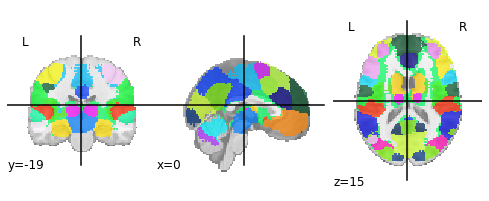

In [16]:
plotting.plot_roi(atlas)

In [12]:
atlas_ho = nilearn.datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
from nilearn.image import math_img

In [13]:
atlas_img = nib.load(atlas_ho.filename)

In [14]:
def embed_tphate_roi(X, sub, task, roi):
    outfn = f'RestMovie/data/embeddings/sub-{sub:02d}_{task}_tphate_embedding_2d_t4_{roi}.npy'
    op = tphate.TPHATE(verbose=0).fit(X)
    e = op.transform(X)
    opt_t = op.optimal_t
    drop = op.dropoff
    x = tphate.TPHATE(verbose=0, n_components=2, t=4).fit_transform(X)
    np.save(outfn, x)

    title=f'sub {sub}'
    if opt_t !=None: title+=f' drop={drop}, opt_t={opt_t}'

    filename=f'RestMovie/plots/sub-{sub:02d}_{task}_tphate_{roi}.png'
    scprep.plot.scatter2d(x, c=np.arange(len(x)), title=title, ticks=False, filename=filename)
    plt.close()
    return opt_t, drop

def return_a_value(X,sub,task,roi):
    return np.random.random()

In [24]:
df = pd.DataFrame(atlas_ho)
atlas_img = nib.load(atlas_ho.filename)
dim_res = []
ac_res=[]
sum_vol = None
for roi_id in df.index[1:6]:
    roi_mask_img = math_img(f"img == {roi_id}", img=atlas_img)
    masker = NiftiMasker(roi_mask_img, standardize=True)
    roi_data = masker.fit_transform(nii)
    tokens = df.iloc[roi_id]['labels'].split()
    roi_str = '_'.join(tokens)
    a=return_a_value(roi_data, sub, task, roi_str)
    # expand
    v = np.repeat(a, roi_data.shape[1]).reshape(1,-1)
    
    print(roi_str, roi_data.shape, a)
    res_img = masker.inverse_transform(v)
    if sum_vol == None:
        sum_vol = res_img
    else:
        sum_vol = math_img(f"img1 + img2", img1=sum_vol, img2=res_img)
        

Frontal_Pole (93, 15397) 0.24683192487353778
Insular_Cortex (93, 2341) 0.6747955603070013
Superior_Frontal_Gyrus (93, 5080) 0.07383126065863921
Middle_Frontal_Gyrus (93, 5316) 0.6301694499816822
Inferior_Frontal_Gyrus,_pars_triangularis (93, 1103) 0.5925736246784521


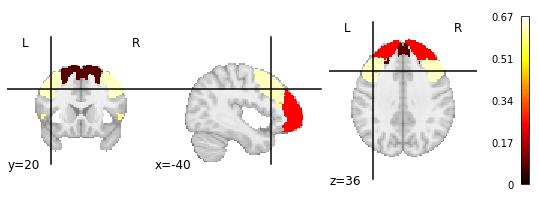

In [25]:

plotting.plot_stat_map(sum_vol)

In [114]:
results = pd.DataFrame(columns=['subject','region','task','dimension','autocorr'])

df = pd.DataFrame(atlas_ho)
atlas_img = nib.load(atlas_ho.filename)
dim_res = []
ac_res=[]
for roi_id in df.index[1:]:
    roi_mask_img = math_img(f"img == {roi_id}", img=atlas_img)
    masker = NiftiMasker(roi_mask_img, standardize=True)
    roi_data = masker.fit_transform(nii)
    tokens = df.iloc[roi_id]['labels'].split()
    roi_str = '_'.join(tokens)
    print(roi_str, roi_data.shape)
    d,a=embed_tphate_roi(roi_data, sub, task, roi_str)
    dim_res.append(d)
    ac_res.append(a)


# roi_id = df[df['labels']=='Superior Frontal Gyrus'].index[0]
# roi_mask_img = math_img(f"img == {roi_id}", img=atlas_ho.filename)
# masker = NiftiMasker(roi_mask_img, standardize=True)
# roi_data.shape, np.mean(roi_data)

Frontal_Pole (93, 15397)
Insular_Cortex (93, 2341)
Superior_Frontal_Gyrus (93, 5080)
Middle_Frontal_Gyrus (93, 5316)
Inferior_Frontal_Gyrus,_pars_triangularis (93, 1103)
Inferior_Frontal_Gyrus,_pars_opercularis (93, 1384)
Precentral_Gyrus (93, 8573)
Temporal_Pole (93, 4711)
Superior_Temporal_Gyrus,_anterior_division (93, 521)
Superior_Temporal_Gyrus,_posterior_division (93, 1830)
Middle_Temporal_Gyrus,_anterior_division (93, 848)
Middle_Temporal_Gyrus,_posterior_division (93, 2525)
Middle_Temporal_Gyrus,_temporooccipital_part (93, 2004)
Inferior_Temporal_Gyrus,_anterior_division (93, 647)
Inferior_Temporal_Gyrus,_posterior_division (93, 1942)
Inferior_Temporal_Gyrus,_temporooccipital_part (93, 1470)
Postcentral_Gyrus (93, 6895)
Superior_Parietal_Lobule (93, 2908)
Supramarginal_Gyrus,_anterior_division (93, 1742)
Supramarginal_Gyrus,_posterior_division (93, 2259)
Angular_Gyrus (93, 2409)
Lateral_Occipital_Cortex,_superior_division (93, 9779)
Lateral_Occipital_Cortex,_inferior_division (

In [13]:
df = []
for ATLAS_NAME in ['Shaefer','Destrieux','HarvardOxford']:
    atlas_res = pd.read_csv(f'RestMovie/results/{ATLAS_NAME}_parcel_tphate_results.csv', index_col=0)
    atlas_res['atlas'] = np.repeat(ATLAS_NAME, len(atlas_res))
    df.append(atlas_res)
atlas_res = pd.concat(df).reset_index()

In [22]:
atlas_res.groupby(['task','atlas']).std()

index   subject      roi_id  dimension  autocorr
task     atlas                                                               
AERONAUT Destrieux       43.312341  3.453012   43.312341   3.012606  3.705395
         HarvardOxford   13.865440  3.455053   13.865440   3.415564  3.685733
         Shaefer        115.481723  3.452412  115.481723   2.908612  3.746299
MICKEY   Destrieux       43.314749  3.317731   43.314749   3.135319  2.798798
         HarvardOxford   13.867852  3.320085   13.867852   3.704127  2.801635
         Shaefer        115.484129  3.317039  115.484129   2.758015  2.878790
REST     Destrieux       43.312341  3.453012   43.312341   3.567762  6.953624
         HarvardOxford   13.865440  3.455053   13.865440   4.825340  6.906568
         Shaefer        115.481723  3.452412  115.481723   3.088127  6.838690

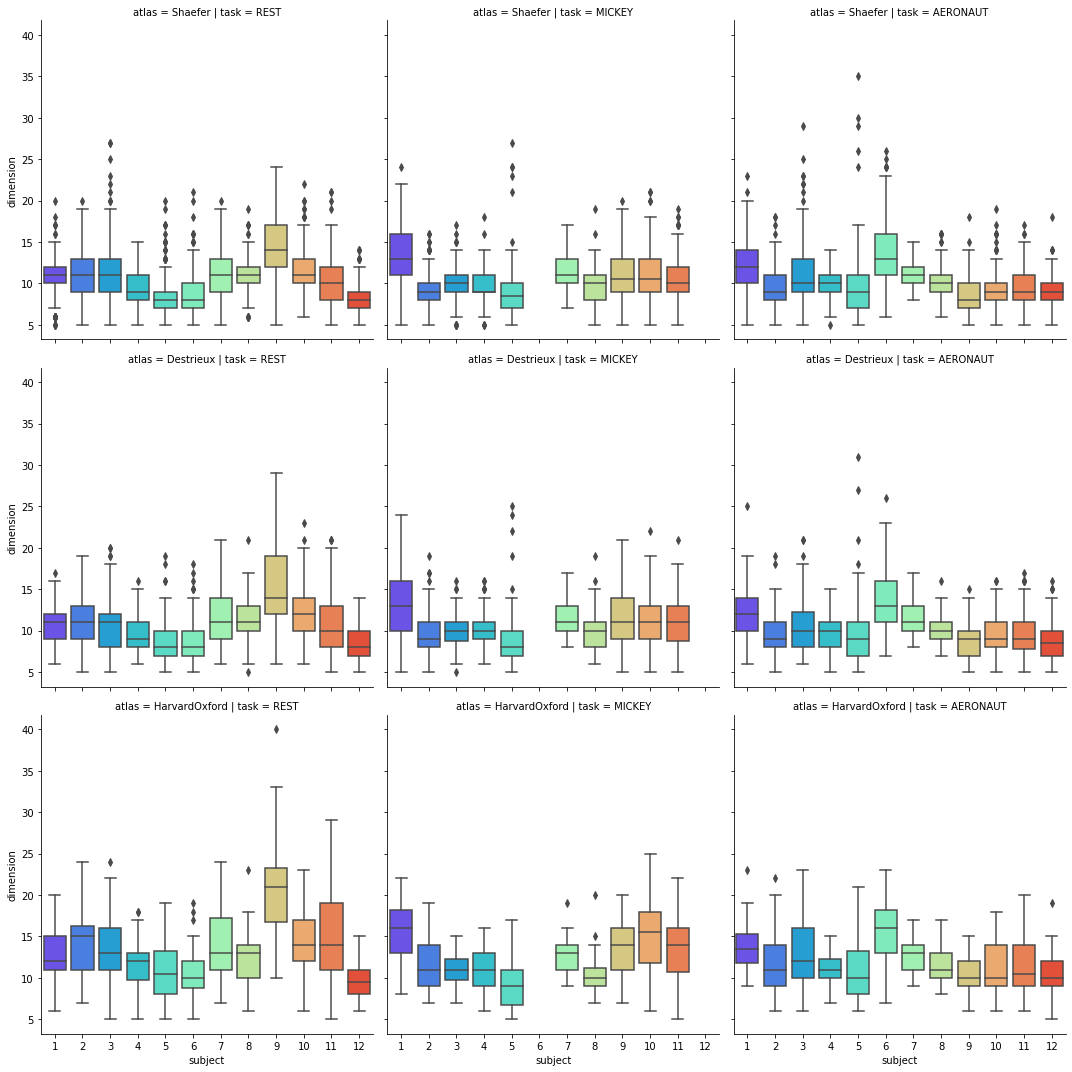

In [18]:
sns.catplot(row='atlas', y='dimension', x='subject', data=atlas_res, col='task', kind="box", palette='rainbow')

In [10]:
average_volumes = {}
std_volumes = {}
median_volumes = {}
df = pd.DataFrame(columns=['statistic', 'atlas', 'task', 'subject', "value"])

df_stat = pd.DataFrame(columns=['statistic', 'atlas', 'task', 'subject', "value"])

for ATLAS_NAME in ['Shaefer','Destrieux','HarvardOxford',]:
    print(f"Running {ATLAS_NAME}")
    
    for task, subject_list in config.RM_SUBJECTS.items():
        all_vols = np.array([1])
        for i,sub_id in enumerate(subject_list):
            outfn = f'RestMovie/results/PARCEL_{ATLAS_NAME}/sub-{sub_id:02d}_{task}_tphate_autocorr_{ATLAS_NAME}.nii.gz'
            vol = nib.load(outfn)
            vol_data = np.squeeze(vol.get_fdata())
            if all_vols.ndim != 4:
                all_vols = np.zeros((len(subject_list), vol_data.shape[0], vol_data.shape[1], vol_data.shape[2]))
            all_vols[i] = vol_data
            vol_vec = np.unique(vol_data
            'statistic':['mean','std'], 'atlas':ATLAS_NAME, 'task':task, 'subject':sub_id, 'value':[np.mean(vol_data]
        print(f"---{task}----")

        avg_vol = np.nanmean(all_vols,axis=0)
        nii_avg = nib.Nifti1Image(avg_vol, vol.affine)
        nii_avg.header.set_zooms(vol.header.get_zooms()[:3])   
        average_volumes[f'{ATLAS_NAME}_{task}'] = nii_avg
        print(f'Mean: min={np.min(avg_vol)}, mean={np.mean(avg_vol)}, max={np.max(avg_vol)}')
        nib.save(nii_avg, f'RestMovie/results/PARCEL_{ATLAS_NAME}/{task}_mean_optimal_t_TPHATE_parcel.nii.gz')

        std_vol = np.nanstd(all_vols,axis=0)
        nii_std = nib.Nifti1Image(std_vol, vol.affine)
        nii_std.header.set_zooms(vol.header.get_zooms()[:3])   
        std_volumes[f'{ATLAS_NAME}_{task}'] = nii_std
        print(f'Std: min={np.min(std_vol)}, mean={np.mean(std_vol)}, max={np.max(std_vol)}')
        nib.save(nii_std, f'RestMovie/results/PARCEL_{ATLAS_NAME}/{task}_std_optimal_t_TPHATE_parcel.nii.gz')


        med_vol = np.nanmedian(all_vols,axis=0)
        nii_med = nib.Nifti1Image(med_vol, vol.affine)
        nii_med.header.set_zooms(vol.header.get_zooms()[:3])   
        median_volumes[f'{ATLAS_NAME}_{task}'] = nii_med
        nib.save(nii_med, f'RestMovie/results/PARCEL_{ATLAS_NAME}/{task}_median_optimal_t_TPHATE_parcel.nii.gz')
        print(f'Median: min={np.min(med_vol)}, mean={np.mean(med_vol)}, max={np.max(med_vol)}')


        print(f"done {task}")
        

SyntaxError: EOL while scanning string literal (<ipython-input-10-e8399c0defab>, line 4)

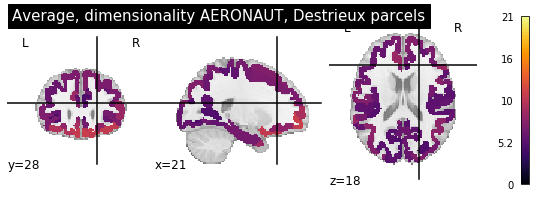

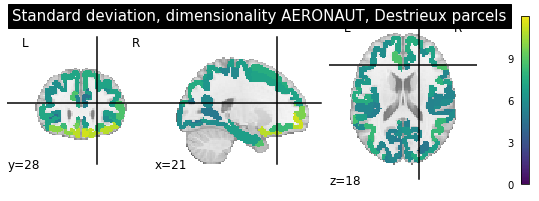

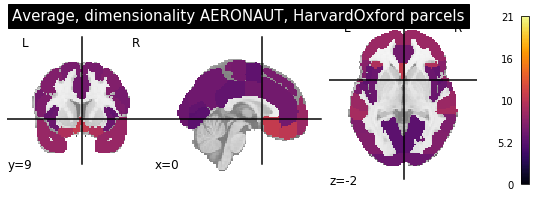

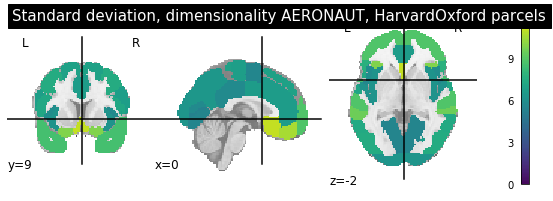

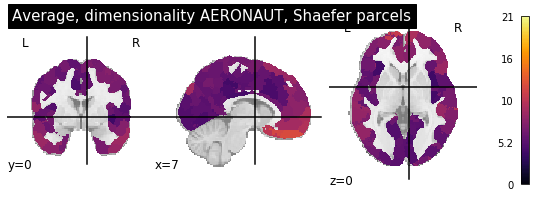

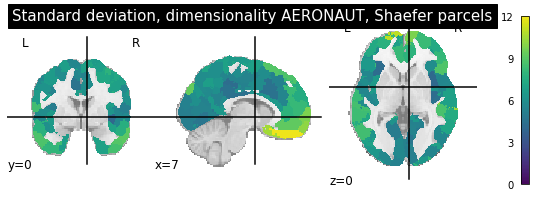

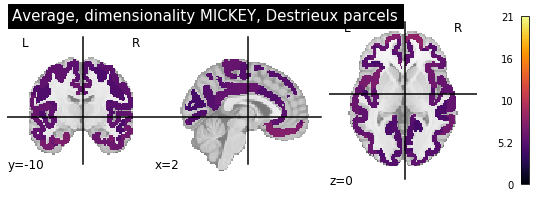

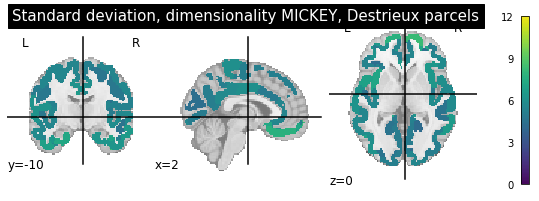

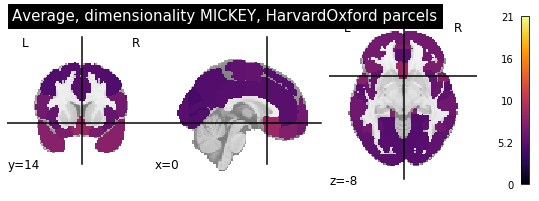

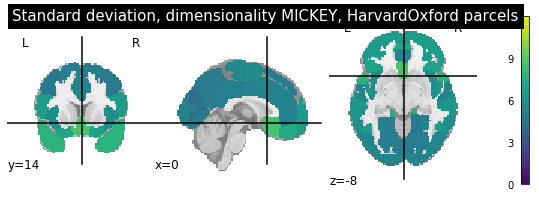

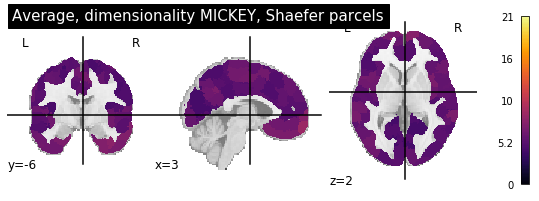

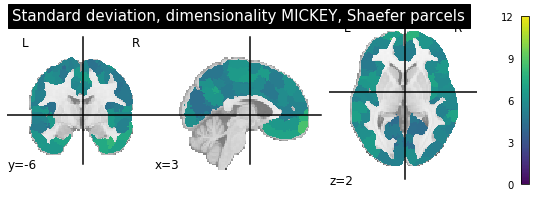

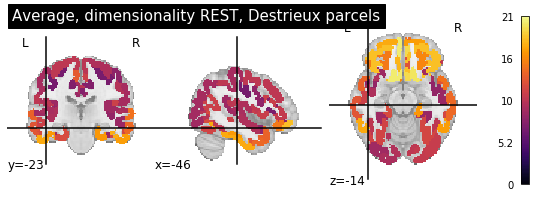

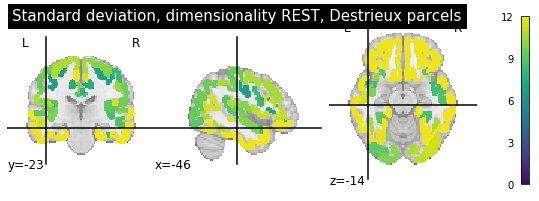

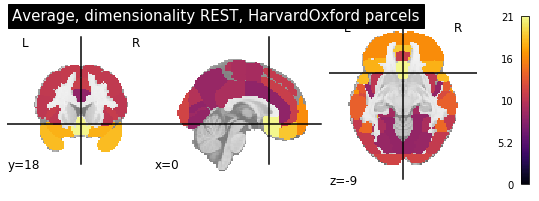

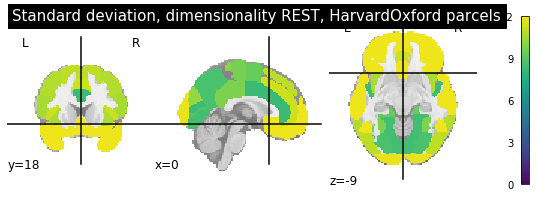

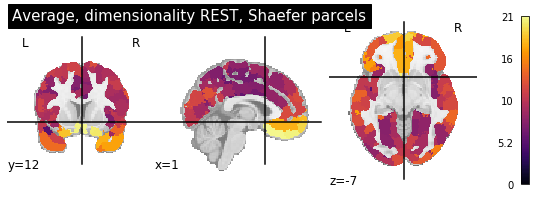

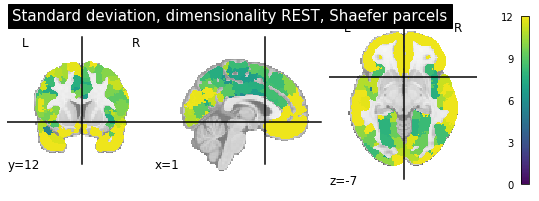

In [25]:
tasks = ["AERONAUT","MICKEY","REST"]

brain_cmap = utils.get_brain_cmap(mpl_colorname='inferno')
std_cmap = utils.get_brain_cmap(mpl_colorname='viridis')
for task in tasks:
    for atlas in ['Destrieux','HarvardOxford','Shaefer']:
        string = f"Average, dimensionality {task}, {atlas} parcels"
        plotting.plot_stat_map(average_volumes[f'{atlas}_{task}'],  vmax=21, cmap=brain_cmap, title=string)
        string = f"Standard deviation, dimensionality {task}, {atlas} parcels"
        plotting.plot_stat_map(average_volumes[f'{atlas}_{task}'], vmax=12, cmap=std_cmap, title=string)
        


## Try SRM - scoring n_components on signal reconstruction

In [27]:
data = np.load('./RestMovie/data/AERONAUT_wb_data.npy')[...,200:600]  # some random number voxels to test


In [30]:
from brainiak.isc import isc
from brainiak.fcma.util import compute_correlation
import brainiak.funcalign.srm
from brainiak import image, io

In [48]:
train_data.shape, test_data.shape, shared_test.shape

((11, 400, 93), (400, 93), (400, 1))

In [58]:
shared

((400, 93), (1, 93), (400, 93))

In [62]:
scores[0]

array([0.58287018, 0.76679084, 0.86919967, 0.90788252, 0.93080002,
       0.93913634, 0.9460162 , 0.95542785, 0.96135466, 0.96688468,
       0.9697635 , 0.97227813, 0.97598404, 0.97791685, 0.98175783,
       0.98173707, 0.98574977, 0.98890144, 0.99006037, 0.9902713 ,
       0.99023726, 0.99255969, 0.99244284, 0.99307298, 0.99369175,
       0.99451822, 0.99484527, 0.99556426, 0.99584916, 0.9961592 ,
       0.99647476, 0.99691839, 0.99719387, 0.99739128, 0.99780762,
       0.99766955, 0.9981597 , 0.99828187, 0.99860353, 0.99863514,
       0.99876146, 0.9988117 , 0.99894467, 0.99887734, 0.99914225,
       0.99928715, 0.99932803, 0.99938606, 0.99942197, 0.99947774,
       0.9995475 , 0.99957288, 0.99965804, 0.99967782, 0.99971555,
       0.99973965, 0.99978407, 0.99981096, 0.99979764, 0.9998442 ,
       0.99985824, 0.99986955, 0.99989106, 0.99989669, 0.99991905,
       0.99992164, 0.99992973, 0.99993625, 0.99994772, 0.99995621,
       0.9999586 , 0.99996649, 0.99997519, 0.99997482, 0.99997

In [78]:
res = np.zeros((len(all_sub_idx), len(srm_k_to_test)))

in_data = np.swapaxes(data, 1,2)
train_data = in_data[...,:46]
test_data = in_data[..., 46:]
for i, k in enumerate(np.arange(1,46)):
    srm = brainiak.funcalign.srm.SRM(n_iter=10, features=k)
    srm.fit(train_data)
    W = srm.w_
    for j in range(len(in_data)):
        da = test_data[j]
        shared = W[j].T.dot(da)
        recon = W[j].dot(shared)
        res[j,i]=np.corrcoef(da.ravel(), recon.ravel())[0,1]
        


In [81]:
res.shape

(12, 91)

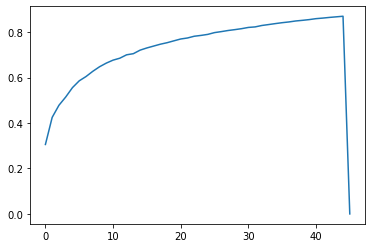

In [82]:
plt.plot(np.mean(res[:, :46], axis=0))

In [64]:
all_sub_idx = np.arange(data.shape[0])
srm_k_to_test = np.arange(1, data.shape[1]-1, 1)
scores = np.zeros((len(all_sub_idx), len(srm_k_to_test)))

print(f"Expecting {scores.shape} scores")
for test_idx in all_sub_idx:
    train_idx = np.setdiff1d(all_sub_idx, test_idx)
    train_data = np.swapaxes(data[train_idx],1,2)
    test_data = data[test_idx].T
    for i, k in enumerate(srm_k_to_test):
        srm = brainiak.funcalign.srm.SRM(n_iter=10, features=k)
        srm.fit(train_data)
        w_new = srm.transform_subject(test_data)
        shared_test = w_new.T.dot(test_data)
        recon_test = w_new.dot(shared_test)
        scores[test_idx, i] = np.corrcoef(test_data.ravel(), recon_test.ravel())[0, 1]
    print(f"done {test_idx}")

Expecting (12, 91) scores
done 0
done 1
done 2
done 3
done 4
done 5
done 6
done 7
done 8
done 9
done 10
done 11


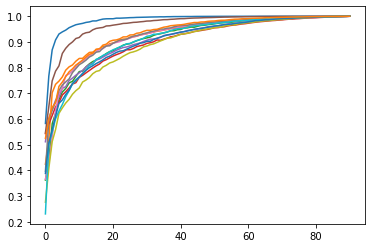

In [67]:
plt.plot(scores.T)

In [ ]:


all_sub_idx = np.arange(data.shape[0])
srm_k_to_test = np.arange(1, 100, 1)
scores = np.zeros((len(all_sub_idx), len(srm_k_to_test)))

print(f"Expecting {scores.shape} scores")
for test_idx in all_sub_idx:
    train_idx = np.setdiff1d(all_sub_idx, test_idx)
    train_data = np.swapaxes(data[train_idx],1,2)
    test_data = data[test_idx].T
    for k in srm_k_to_test:
        srm = brainiak.funcalign.srm.SRM(n_iter=10, features=k)
        srm.fit(train_data)
        shared_test = srm.transform_subject(test_data)
        w0 = srm.w_[0]
        recon_test = w0.dot(shared_test)
        scores[test_idx, k-1] = np.corrcoef(shared_test.ravel(), recon_test.ravel())[0, 1]

In [2]:
import nilearn.mass_univariate

In [13]:
key='REST-AERONAUT'
nii = nib.load(glob.glob(f'./RestMovie/results/AGGREGATE/{key}_diff_tstat_optimal_t_whole_brain_SL_rad5.nii.gz')[0])
nii_avg=nib.load(glob.glob(f'./RestMovie/results/AGGREGATE/{key}_diff_average_optimal_t_whole_brain_SL_rad5.nii.gz')[0])

In [17]:
from nilearn.image import threshold_img, math_img

x=threshold_img(
    nii,
    threshold=1.796,
    cluster_threshold=30,
    two_sided=True,
) # these are now thresholded t-stats -- so anywhere that is red is signif, now apply as mas
mask = math_img(f'np.where(img > 0, 1, 0)', img=x)
masked_img = math_img(f'img * img2', img=nii_avg, img2=mask)

(<Figure size 288x324 with 5 Axes>,
  <matplotlib.axes._subplots.AxesSubplot at 0x2b5be8425710>])

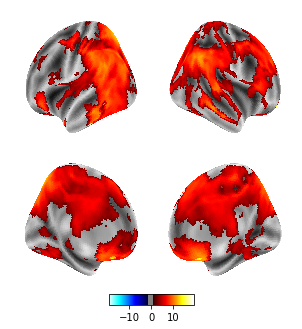

In [18]:
plotting.plot_img_on_surf(masked_img, threshold=1, inflate=True)

(<Figure size 288x324 with 5 Axes>,
  <matplotlib.axes._subplots.AxesSubplot at 0x2b5bec3597b8>])

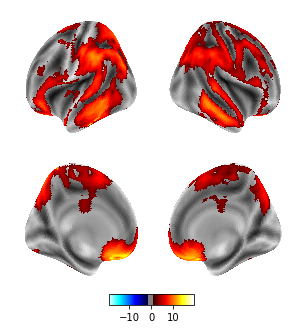

In [19]:
key='REST-MICKEY'
nii = nib.load(glob.glob(f'./RestMovie/results/AGGREGATE/{key}_diff_tstat_optimal_t_whole_brain_SL_rad5.nii.gz')[0])
nii_avg=nib.load(glob.glob(f'./RestMovie/results/AGGREGATE/{key}_diff_average_optimal_t_whole_brain_SL_rad5.nii.gz')[0])

x=threshold_img(
    nii,
    threshold=1.796,
    cluster_threshold=30,
    two_sided=True,
) # these are now thresholded t-stats -- so anywhere that is red is signif, now apply as mas
mask = math_img(f'np.where(img > 0, 1, 0)', img=x)
masked_img = math_img(f'img * img2', img=nii_avg, img2=mask)
plotting.plot_img_on_surf(masked_img, threshold=1, inflate=True)